<a href="https://colab.research.google.com/github/trillion-boy/UniVLA/blob/claude%2Ffoveated-tokenization-experiment-EQyFt/Foveation_try.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1

In [ ]:
%%bash
wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
bash /tmp/miniconda.sh -b -f -p /usr/local
conda --version

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
conda 26.3.2


2

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


3

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda create -n univla python=3.10.12 -y
conda run -n univla python --version

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - \ | / - \ | done
Channels:
 - defaults
Platform: linux-64
Solving environment: - done

## Package Plan ##

  environment location: /usr/local/envs/univla

  added / updated specs:
    - python=3.10.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    packaging-26.0             |  py310h06a4308_0         165 KB
    python-3.10.12             |       h955ad1f_0        26.8 MB
    setuptools-82.0.1          |  py310h06a4308_0         1.2 MB
    wheel-0.46.3               |  py310h06a4308_0          54 KB
    ------------------------------------------------------------
                                           Total:        28.2 MB

The following NEW packages will be INSTALLED:

  _libgcc_mutex      pkgs/main/linux-64::_libgcc_mutex-0.1-main 
  _openmp_mutex      pkgs/main/linux-64:

4

In [ ]:
%%bash
apt-get update -yqq
apt-get -yqq install libegl1-mesa libegl1 libgl1 libosmesa6-dev
apt-get install -yqq --no-install-recommends libvulkan-dev vulkan-tools
apt-get install -yqq ffmpeg

Selecting previously unselected package libpciaccess-dev:amd64.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../0-libpciaccess-dev_0.16-3_amd64.deb ...
Unpacking libpciaccess-dev:amd64 (0.16-3) ...
Selecting previously unselected package libdrm-dev:amd64.
Preparing to unpack .../1-libdrm-dev_2.4.113-2~ubuntu0.22.04.1_amd64.deb ...
Unpacking libdrm-dev:amd64 (2.4.113-2~ubuntu0.22.04.1) ...
Selecting previously unselected package libegl1-mesa:amd64.
Preparing to unpack .../2-libegl1-mesa_23.0.4-0ubuntu1~22.04.1_amd64.deb ...
Unpacking libegl1-mesa:amd64 (23.0.4-0ubuntu1~22.04.1) ...
Selecting previously unselected package libglx-dev:amd64.
Preparing to unpack .../3-libglx-dev_1.4.0-1_amd64.deb ...
Unpacking libglx-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgl-dev:amd64.
Preparing to unpack .../4-libgl-dev_1.4.0-1_amd64.deb ...
Unpacking libgl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package mesa-commo

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


5

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda run -n univla conda install -c conda-forge gcc=12.1.0 gxx_linux-64 -y
conda run -n univla pip install mediapy decord
conda run -n univla pip install numpy==1.24.4
conda run -n univla pip install transformers==4.44.0 tiktoken==0.6.0 pillow
conda run -n univla pip install matplotlib

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: \ | / done

## Package Plan ##

  environment location: /usr/local/envs/univla

  added / updated specs:
    - gcc=12.1.0
    - gxx_linux-64


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    binutils_impl_linux-64-2.36.1|       h193b22a_2        10.4 MB  conda-forge
    binutils_linux-64-2.36     |      hf3e587d_10          24 KB  conda-forge
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    gcc-12.1.0                 |      h9ea6d83_10          24 KB  conda-forge
    gcc_impl_linux-64-12.1.0   |      hea43390_17        56.2 MB  conda-forge
    gcc_linux-64-12.1.0        |      h3bb4806_10          25 KB  conda-forge
    gxx_impl_linux-64-12.1.0   |      hea43390_17        13.9 MB  conda-forge
    gxx_linux-64-12.1.0   

6

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh

# UniVLA — 실험 파일이 있는 브랜치로 클론
if [ ! -d /content/UniVLA ]; then
  git clone --depth 1 -b claude/foveated-tokenization-experiment-EQyFt \
    https://github.com/trillion-boy/UniVLA.git /content/UniVLA
fi

# SimplerEnv 클론
if [ ! -d /content/SimplerEnv ]; then
  git clone https://github.com/simpler-env/SimplerEnv \
    --recurse-submodules -q /content/SimplerEnv
fi

# SAPIEN 2.2.2
conda run -n univla pip install sapien==2.2.2

# ManiSkill2_real2sim
conda run -n univla pip install --no-deps -e /content/SimplerEnv/ManiSkill2_real2sim

# gym
conda run -n univla conda install -c conda-forge gym=0.21.0 -y

# ruckig
conda run -n univla pip install ruckig

# opencv + 기타
conda run -n univla pip install \
  transforms3d "opencv-python-headless==4.8.1.78" \
  "trimesh==3.22.5" "open3d==0.17.0" "mplib==0.0.9" "gymnasium==0.29.1"

# mani-skill2 누락 deps
conda run -n univla pip install \
  gdown GitPython h5py \
  imageio "imageio[ffmpeg]" \
  rtree tabulate

# numpy 고정
conda run -n univla pip install "numpy==1.24.4"

# SimplerEnv
conda run -n univla pip install --no-deps -e /content/SimplerEnv

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 146.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 194.8 MB/s  0:00:00
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.6 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4

Obtaining file:///content/SimplerEnv/ManiSkill2_real2sim
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  

Cloning into '/content/UniVLA'...
Updating files: 100% (842/842), done.
    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mani-skill2-real2sim 0.5.3 requires gdown>=4.6.0, which is not installed.
mani-skill2-real2sim 0.5.3 requires GitPython, which is not installed.
mani-skill2-real2sim 0.5.3 requires gymnasium<1.0,>=0.28.1, which is not installed.
mani-skill2-real2sim 0.5.3 requires h5py, which is not installed.
mani-skill2-real2sim 0.5.3 requires imageio, which is not installed.
mani-skill2-real2sim 0.5.3 requires imageio[ffmpeg], which is not installed.
mani-skill2-real2sim 0.5.3 requires rtree, which is not installed.
mani-skill2-real2sim 0.5.3 requires scipy, which is not installed.
mani-skill2-real2sim 0.5.3 requires tabulate, which is not installed.
mani-skill2-real2sim 0.5.3 requires trimes

7

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda run -n univla pip install "opencv-python==4.8.1.78"
conda run -n univla pip install "numpy==1.24.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 121.9 MB/s  0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^


8

In [ ]:
%%bash
apt-get install -yqq xvfb
echo "xvfb done"

xvfb done


9

In [ ]:
%%bash
mkdir -p /etc/vulkan/icd.d
cat > /etc/vulkan/icd.d/nvidia_icd.json << 'EOF'
{
    "file_format_version": "1.0.0",
    "ICD": {
        "library_path": "libGLX_nvidia.so.0",
        "api_version": "1.2.155"
    }
}
EOF
mkdir -p /usr/share/vulkan/implicit_layer.d
echo "Vulkan config done"

Vulkan config done


10

In [ ]:
# Python Cell implementation (No %%bash)
import site, os, sys

# 1. 파일 위치 찾기
rc_path = None
search_dirs = ["/usr/local/envs/univla/lib/python3.10/site-packages"]
for sp in search_dirs:
    p = os.path.join(sp, 'sapien', 'core', 'renderer_config.py')
    if os.path.exists(p):
        rc_path = p
        break

if rc_path is None:
    print("ERROR: renderer_config.py 못 찾음")
    sys.exit(1)

print(f"패치 대상: {rc_path}")

# 2. 원본 내용 확인
with open(rc_path, 'r') as f:
    content = f.read()

print("=== 원본 ===")
print(content[:300])

패치 대상: /usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py
=== 원본 ===
import os
from typing import Union

import pkg_resources
from warnings import warn

from .pysapien import SapienRenderer, get_global_render_config

_global_render_config = get_global_render_config()


def _set_viewer_shader_dir(shader_dir):
    if os.path.exists(shader_dir):
        _global_render_c


11

In [ ]:
import os

# site-packages에 pkg_resources 패키지 직접 생성
site_packages = "/usr/local/envs/univla/lib/python3.10/site-packages"
pr_dir = os.path.join(site_packages, "pkg_resources")
os.makedirs(pr_dir, exist_ok=True)

shim = '''"""pkg_resources shim — importlib.metadata 기반"""
import importlib
import importlib.metadata as _meta
import os

def get_distribution(name):
    class _Dist:
        try:
            version = _meta.version(name)
        except Exception:
            version = "0.0.0"
    return _Dist()

def require(requirements):
    pass

def resource_filename(package_name, resource_name):
    try:
        mod = importlib.import_module(package_name)
        return os.path.join(os.path.dirname(mod.__file__), resource_name)
    except Exception:
        return resource_name

def resource_string(package_name, resource_name):
    path = resource_filename(package_name, resource_name)
    with open(path, "rb") as f:
        return f.read()

def resource_exists(package_name, resource_name):
    path = resource_filename(package_name, resource_name)
    return os.path.exists(path)

def resource_stream(package_name, resource_name):
    path = resource_filename(package_name, resource_name)
    return open(path, "rb")

class WorkingSet:
    def __iter__(self): return iter([])
    def __contains__(self, item): return False
    def require(self, *a, **kw): pass

working_set = WorkingSet()
'''

init_file = os.path.join(pr_dir, "__init__.py")
with open(init_file, "w") as f:
    f.write(shim)

print(f"생성: {init_file}")
print(f"크기: {os.path.getsize(init_file)} bytes")

생성: /usr/local/envs/univla/lib/python3.10/site-packages/pkg_resources/__init__.py
크기: 1184 bytes


12

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
conda run -n univla python -c "import pkg_resources; print('pkg_resources OK')"
conda run -n univla python -c "import sapien.core; print('sapien OK')"
conda run -n univla python -c "import simpler_env; print('simpler_env OK')"

pkg_resources OK
sapien OK
simpler_env OK


Cell 11 — 알고리즘 테스트 (SimplerEnv 없이, 더미 이미지)
렌더링 없이 tokenization 로직만 먼저 확인

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh

conda run -n univla --no-capture-output \
  python /content/UniVLA/experiments/foveated_tokenization/run_steps123.py \
    --dummy-image \
    --n-samples 2 \
    --output-dir /content/foveated_exp

    #/content/foveated_exp/ 에 PNG 4장 생기면 성공.

[Step1] Using dummy image (SimplerEnv skipped)

[Step2/3] Running foveated tokenization & visualization...
  [Step3] Saved visualization → /content/foveated_exp/foveated_sample_00.png
  [Step3] Saved layout vis → /content/foveated_exp/foveated_layout_00.png
  [Step3] Saved visualization → /content/foveated_exp/foveated_sample_01.png
  [Step3] Saved layout vis → /content/foveated_exp/foveated_layout_01.png

 Done. 4 files saved to /content/foveated_exp/
  /content/foveated_exp/foveated_sample_00.png
  /content/foveated_exp/foveated_layout_00.png
  /content/foveated_exp/foveated_sample_01.png
  /content/foveated_exp/foveated_layout_01.png


In [ ]:
%%bash
cd /content/UniVLA && git pull origin claude/foveated-tokenization-experiment-EQyFt

Already up to date.


From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD


Cell 12 — 실제 SimplerEnv 실험

In [ ]:
%%bash
source /usr/local/etc/profile.d/conda.sh
export MUJOCO_GL=osmesa

xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
  conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_steps123.py \
      --task widowx_put_eggplant_in_basket \
      --n-samples 3 \
      --output-dir /content/foveated_exp

[Step1] Making env: widowx_put_eggplant_in_basket
  sample 0: obj_3d=[-0.11948847  0.19007781  0.93872476], pixel_xy=[365 298], img_shape=(480, 640, 3)
  sample 1: obj_3d=[-0.11934444  0.1995378   0.93831086], pixel_xy=[379 303], img_shape=(480, 640, 3)
  sample 2: obj_3d=[-0.11932092  0.19395684  0.93854064], pixel_xy=[371 300], img_shape=(480, 640, 3)

[Step2/3] Running foveated tokenization & visualization...
  [Step3] Saved visualization → /content/foveated_exp/foveated_sample_00.png
  [Step3] Saved layout vis → /content/foveated_exp/foveated_layout_00.png
  [Step3] Saved visualization → /content/foveated_exp/foveated_sample_01.png
  [Step3] Saved layout vis → /content/foveated_exp/foveated_layout_01.png
  [Step3] Saved visualization → /content/foveated_exp/foveated_sample_02.png
  [Step3] Saved layout vis → /content/foveated_exp/foveated_layout_02.png

 Done. 6 files saved to /content/foveated_exp/
  /content/foveated_exp/foveated_sample_00.png
  /content/foveated_exp/foveated_lay

/content/foveated_exp/foveated_sample_00.png


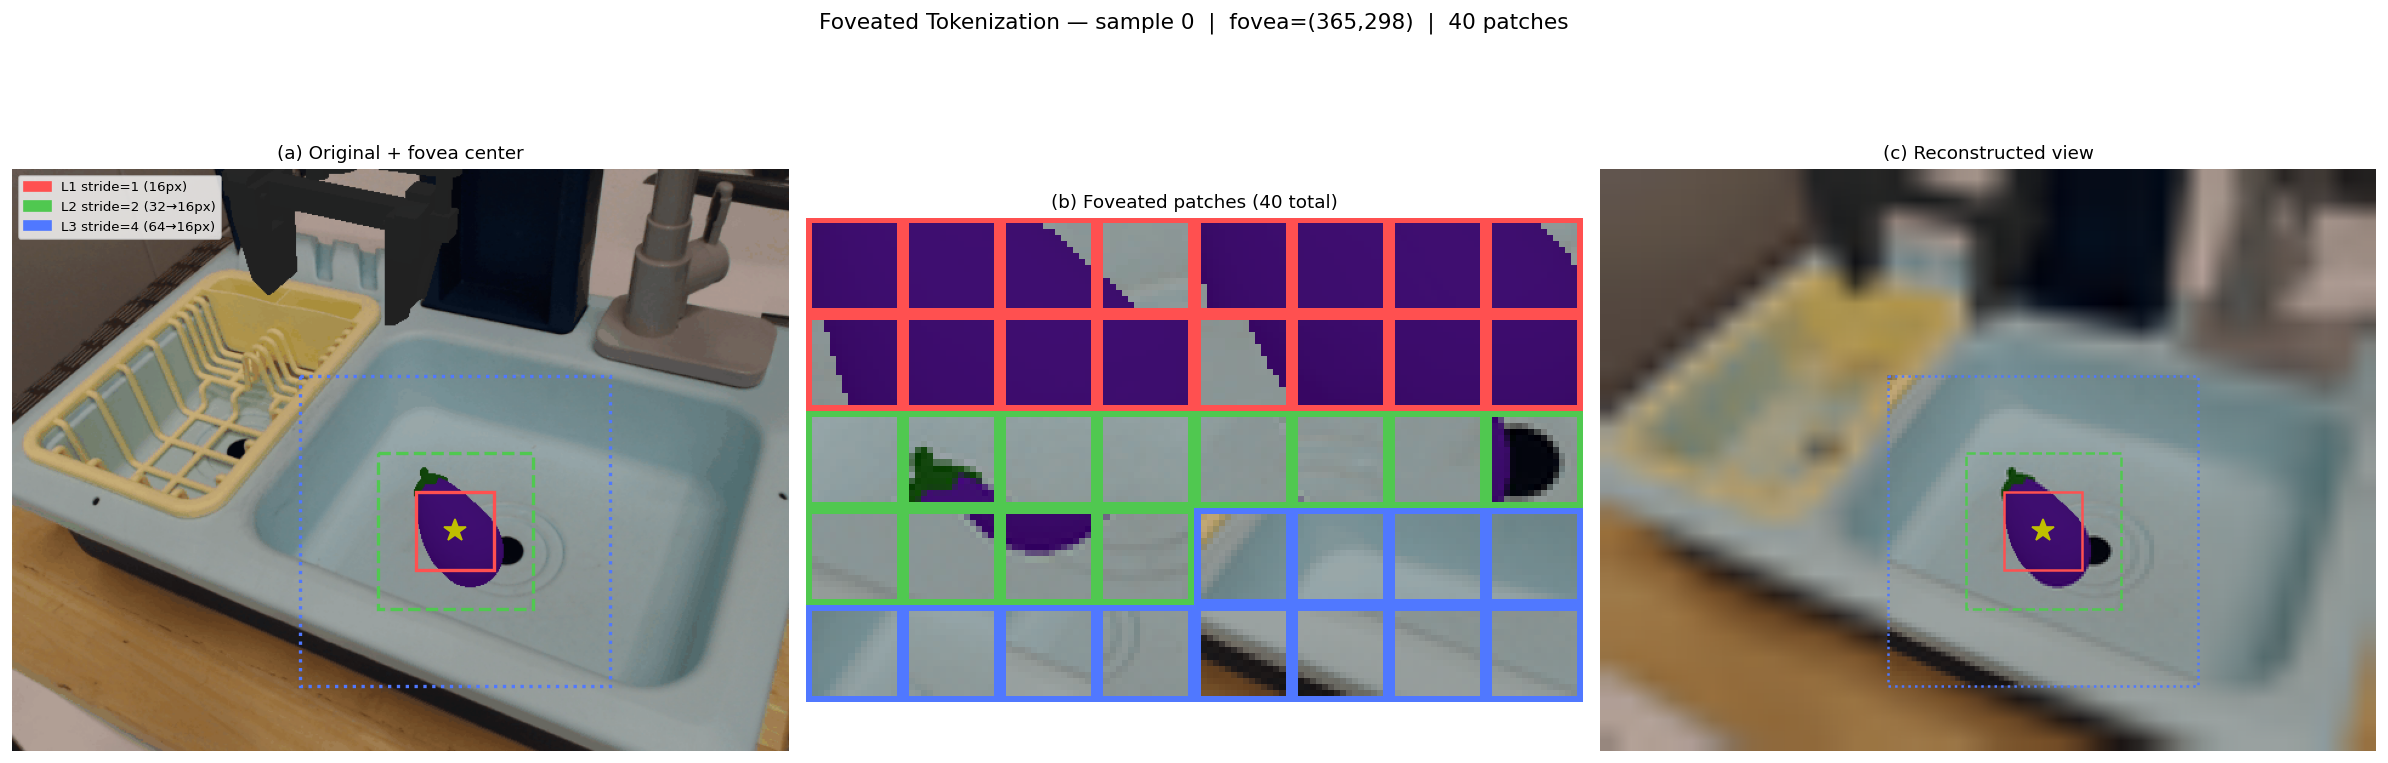

/content/foveated_exp/foveated_sample_01.png


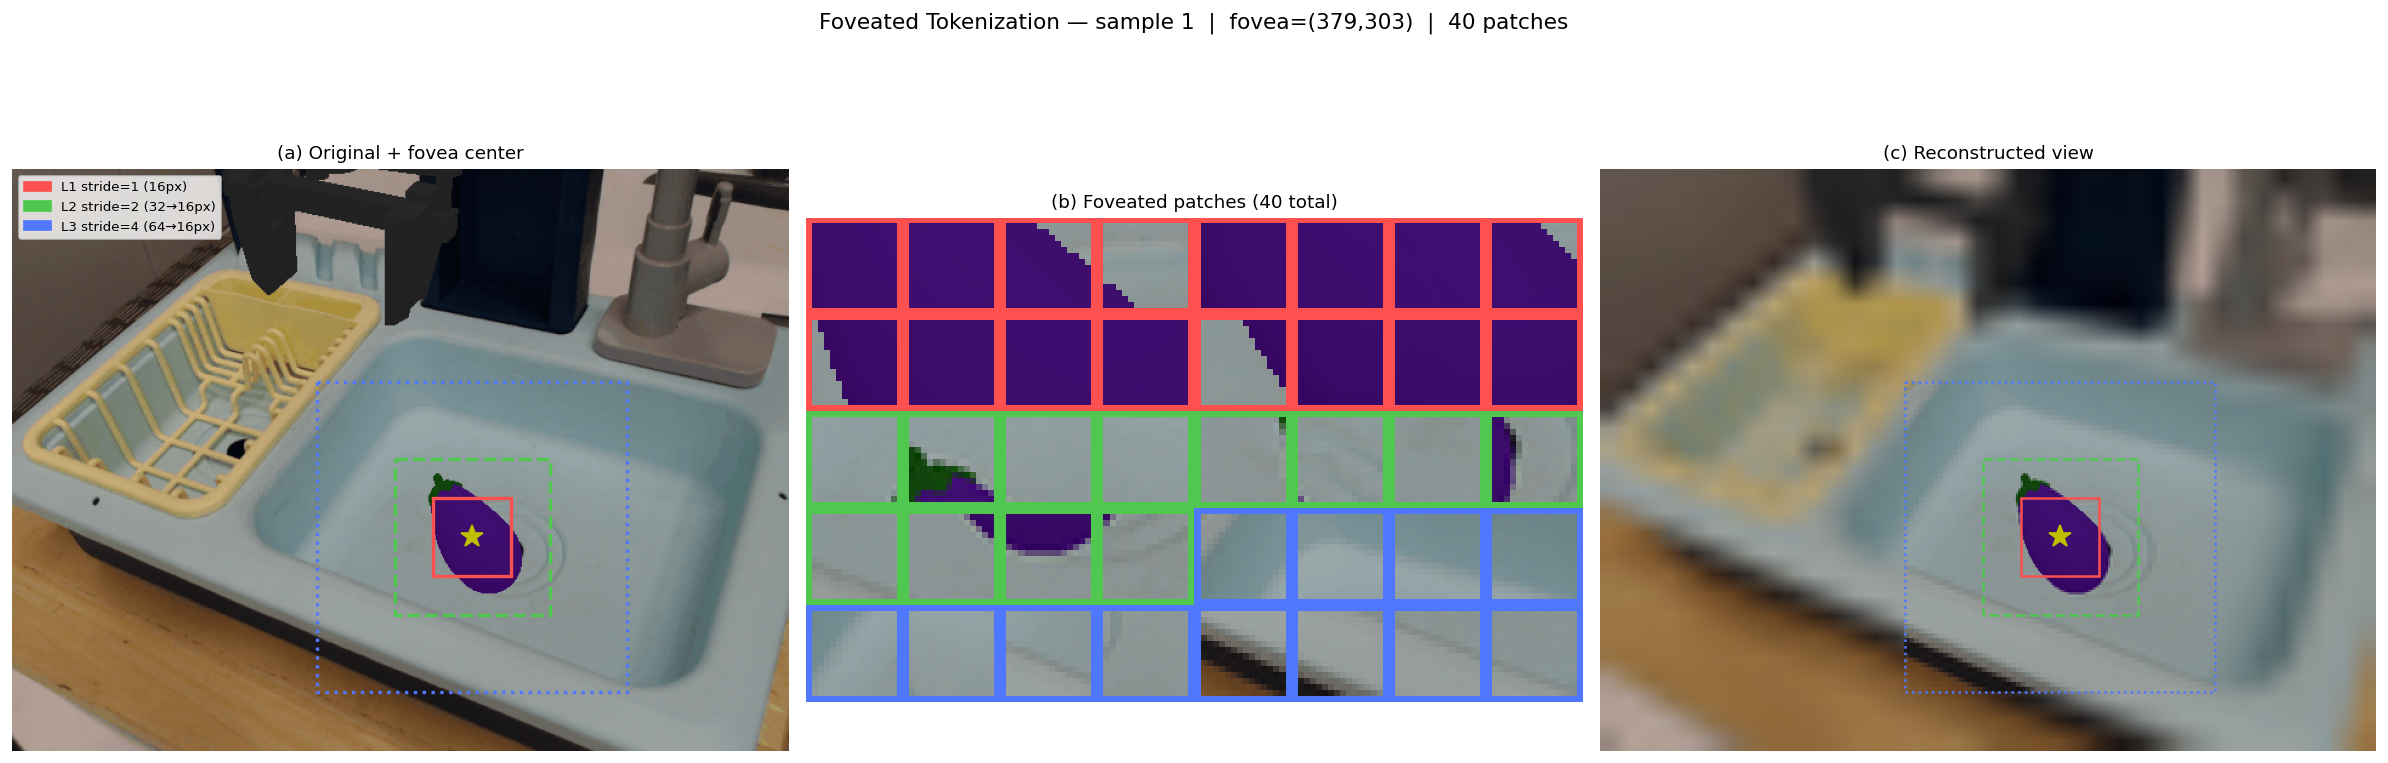

/content/foveated_exp/foveated_sample_02.png


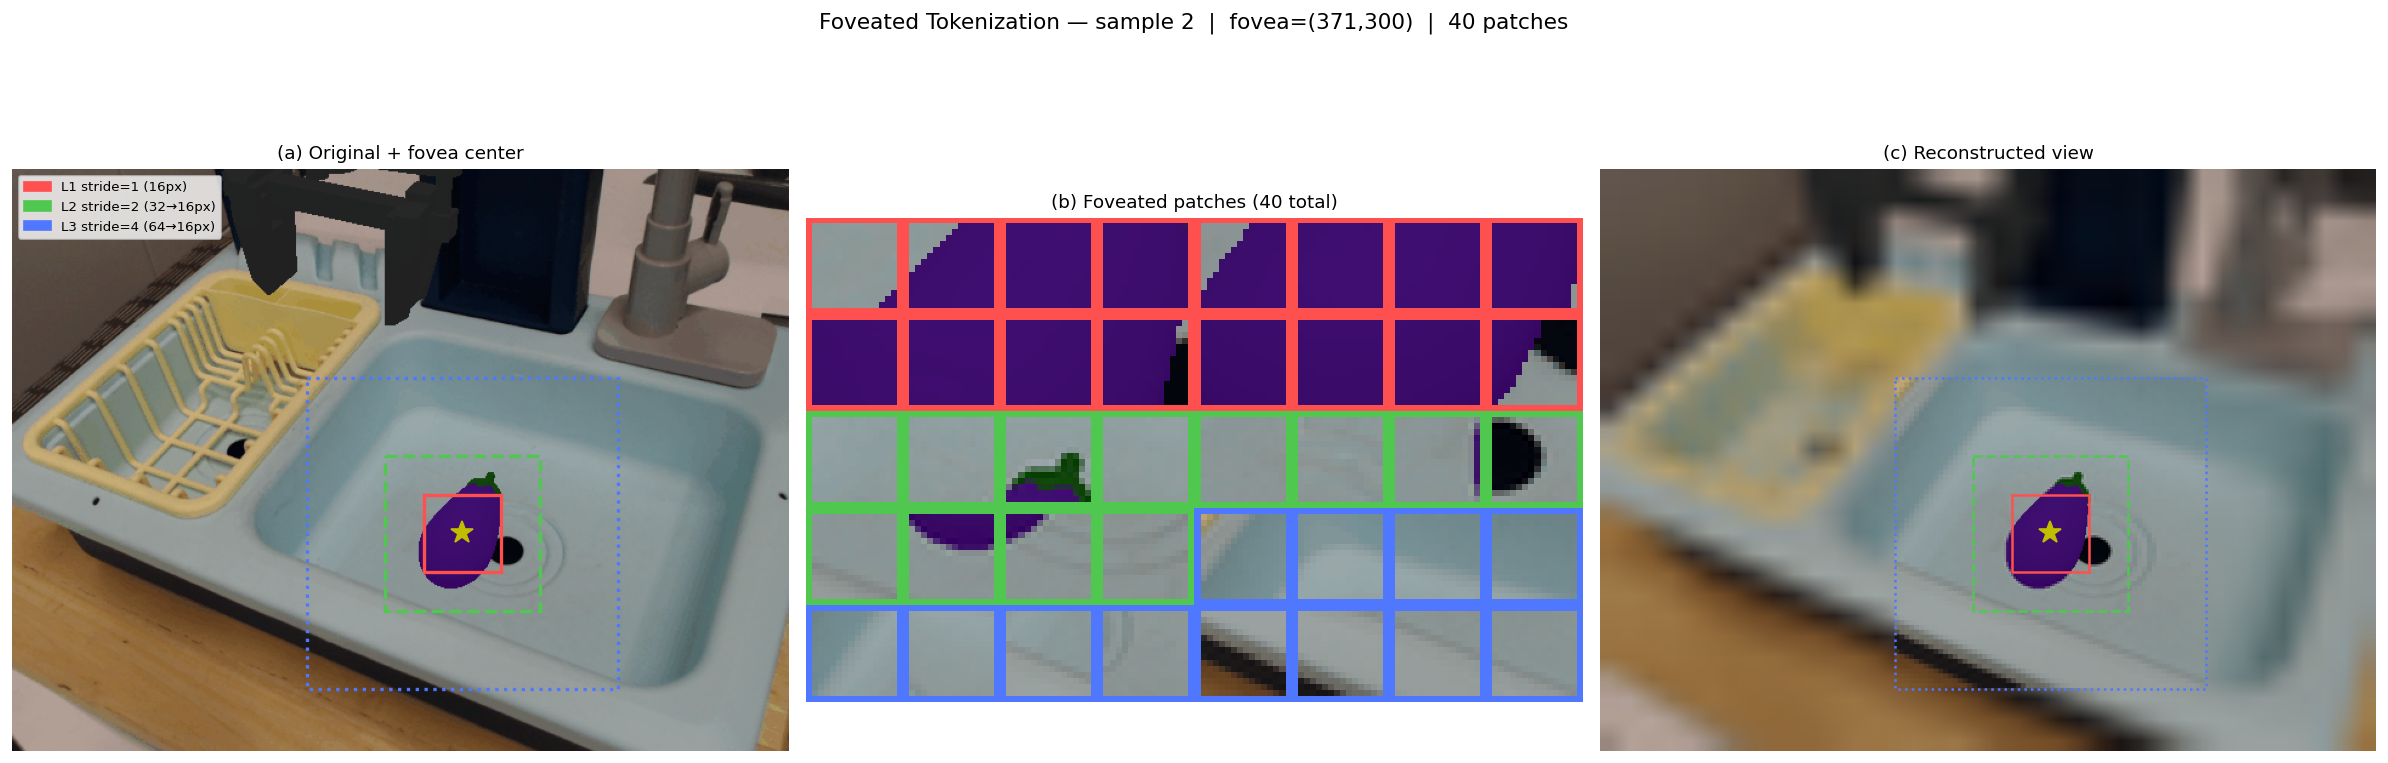

In [ ]:
import glob
from IPython.display import display, Image

for path in sorted(glob.glob("/content/foveated_exp/foveated_sample_*.png")):
    print(path)
    display(Image(path))

In [ ]:
# Cell 13: 최신 코드 가져오기
import subprocess
result = subprocess.run(
    ["git", "pull", "origin", "claude/foveated-tokenization-experiment-EQyFt"],
    cwd="/content/UniVLA", capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

# 새로 추가된 파일 확인
!ls -la /content/UniVLA/experiments/foveated_tokenization/

Already up to date.

From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD

total 240
drwxr-xr-x 4 root root  4096 May 10 00:59 .
drwxr-xr-x 3 root root  4096 May 10 00:33 ..
-rw-r--r-- 1 root root 14191 May 10 00:33 bass_warp.py
-rw-r--r-- 1 root root 89378 May 10 00:33 foveated_inference.py
-rw-r--r-- 1 root root  8066 May 10 00:33 foveated_tokenization.py
-rw-r--r-- 1 root root 12718 May 10 00:33 grounding_dino_wrapper.py
-rwxr-xr-x 1 root root  1888 May 10 00:33 install_dino.sh
-rw-r--r-- 1 root root 18657 May 10 00:33 latent_saccade_eval_colab.ipynb
-rw-r--r-- 1 root root 11114 May 10 00:59 latent_saccade_eval.py
drwxr-xr-x 2 root root  4096 May 10 00:33 lora_training
drwxr-xr-x 2 root root  4096 May 10 00:42 __pycache__
-rw-r--r-- 1 root root 34698 May 10 00:33 run_eval_compare.py
-rwxr-xr-x 1 root root  3163 May 10 00:33 run_eval_compare.sh
-rw-r--r-- 1 root root  2850 May 10 00:33 run.sh
-rw-r--r-- 1 root ro

13

In [ ]:
%%bash
# Grounding DINO 의존성 설치
conda run -n univla pip install "transformers>=4.38.0" torchvision --quiet

# 설치 확인
conda run -n univla python -c "
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torchvision
print('transformers DINO 지원: OK')
print('torchvision:', torchvision.__version__)
"

transformers DINO 지원: OK
torchvision: 0.26.0+cu130


    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^


In [ ]:
# Cell 15-A
%%bash
cat > /tmp/get_raw_frame.py << 'PYEOF'
import sys
sys.path.insert(0, '/content/SimplerEnv')
sys.path.insert(0, '/content/SimplerEnv/ManiSkill2_real2sim')

import simpler_env
import numpy as np
from PIL import Image
import os

env = simpler_env.make("widowx_put_eggplant_in_basket")
obs, _ = env.reset()

cam_obs = obs["image"].get("3rd_view_camera") or list(obs["image"].values())[0]
img = cam_obs.get("rgb", None)
if img is None:
    img = (cam_obs["Color"][..., :3] * 255).astype(np.uint8)
elif img.dtype != np.uint8:
    img = (img * 255).astype(np.uint8)

os.makedirs("/content/foveated_exp", exist_ok=True)
Image.fromarray(img).save("/content/foveated_exp/raw_frame.png")
print(f"OK shape={img.shape}")
env.close()
PYEOF

export MUJOCO_GL=osmesa
xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output python /tmp/get_raw_frame.py

OK shape=(480, 640, 3)


In [ ]:
# Cell 15-B
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

OUTPUT_DIR = "/content/foveated_exp"

# raw 카메라 이미지 로드
test_img = np.array(Image.open(f"{OUTPUT_DIR}/raw_frame.png").convert("RGB"))
print(f"이미지 shape: {test_img.shape}")

# DINO 로딩
print("DINO 모델 로딩...")
processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-tiny"
).eval()
print("로딩 완료")

# 추론
pil_img = Image.fromarray(test_img)
inputs = processor(images=pil_img, text="eggplant.", return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([pil_img.size[::-1]])
try:
    results = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        box_threshold=0.20, text_threshold=0.15,
        target_sizes=target_sizes,
    )[0]
    print("API: box_threshold 버전")
except TypeError:
    results = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=0.20,
        target_sizes=target_sizes,
    )[0]
    print("API: threshold 버전")

print(f"\n검출 결과: {len(results['boxes'])}개")
for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
    print(f"  [{label}]  score={score:.3f}  box={[round(x,1) for x in box.tolist()]}")

# 시각화
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test_img)
if len(results["boxes"]) > 0:
    best = results["scores"].argmax().item()
    box = results["boxes"][best].numpy()
    cx, cy = (box[0]+box[2])/2, (box[1]+box[3])/2
    ax.add_patch(Rectangle(
        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
        linewidth=2, edgecolor="lime", facecolor="none"
    ))
    ax.plot(cx, cy, "r*", markersize=20, label=f"Fovea ({cx:.0f},{cy:.0f})")
    ax.axhline(cy, color="yellow", linewidth=1, alpha=0.5)
    ax.axvline(cx, color="yellow", linewidth=1, alpha=0.5)
    ax.set_title(f"DINO: eggplant 검출\nFovea ({cx:.0f},{cy:.0f})")
else:
    ax.set_title("검출 실패 (score 0.20 미만)")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dino_test.png", dpi=120)
plt.show()

이미지 shape: (480, 640, 3)
DINO 모델 로딩...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

로딩 완료
API: threshold 버전

검출 결과: 1개
  [eggplant]  score=0.491  box=[329.9, 245.4, 405.8, 345.9]


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
/tmp/ipykernel_7564/420397880.py:69: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7564/420397880.py:69: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7564/420397880.py:70: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/dino_test.png", dpi=120)
/tmp/ipykernel_7564/420397880.py:70: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/dino_test.png", dpi=120)


In [ ]:
import sys, os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# sys.path 설정 (재시작 후 필요)
UNIVLA_ROOT = "/content/UniVLA"
EXP_DIR     = f"{UNIVLA_ROOT}/experiments/foveated_tokenization"
OUTPUT_DIR  = "/content/foveated_exp"
for p in [UNIVLA_ROOT, EXP_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from foveated_tokenization import (
    foveated_tokenize,
    reconstruct_foveated_with_context,
    LEVEL_COLORS_RGB, LEVELS, PATCH_OUT,
)

# ── Step 1: raw 이미지 로드 ─────────────────────────────
image = np.array(Image.open(f"{OUTPUT_DIR}/raw_frame.png").convert("RGB"))
H, W = image.shape[:2]
print(f"이미지: {W}×{H}")

# ── Step 2: DINO로 fovea center 검출 ────────────────────
print("DINO 검출 중...")
processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-tiny"
).eval()

pil_img = Image.fromarray(image)
inputs = processor(images=pil_img, text="eggplant.", return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([pil_img.size[::-1]])
try:
    results = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        box_threshold=0.20, text_threshold=0.15,
        target_sizes=target_sizes,
    )[0]
except TypeError:
    results = processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=0.20, target_sizes=target_sizes,
    )[0]

if len(results["boxes"]) > 0:
    best = results["scores"].argmax().item()
    box = results["boxes"][best].numpy()
    cx, cy = int((box[0]+box[2])/2), int((box[1]+box[3])/2)
    print(f"DINO 검출: eggplant @ ({cx},{cy})  score={results['scores'][best]:.3f}")
else:
    cx, cy = W//2, H//2
    print(f"검출 실패 → 이미지 중심 fallback ({cx},{cy})")

# ── Step 3: Foveated tokenization + reconstruction ──────
patches = foveated_tokenize(image, cx, cy)
fov_image = reconstruct_foveated_with_context(image, patches, blur_scale=0.06)
print(f"총 {len(patches)}개 patches: "
      f"L1={sum(p.level==0 for p in patches)}, "
      f"L2={sum(p.level==1 for p in patches)}, "
      f"L3={sum(p.level==2 for p in patches)}")

# ── Step 4: 시각화 (3패널) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (a) 원본 + DINO fovea
ax = axes[0]
ax.imshow(image)
from matplotlib.patches import Rectangle
if len(results["boxes"]) > 0:
    b = results["boxes"][best].numpy()
    ax.add_patch(Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor="lime", facecolor="none"))
ax.plot(cx, cy, "r*", markersize=15)
# fovea level 경계 표시
colors = ["red", "green", "blue"]
strides = [1, 2, 4]
for lvl_idx, (stride, color) in enumerate(zip(strides, colors)):
    coverage = PATCH_OUT * stride
    total = 4 * coverage
    x0 = cx - total//2; y0 = cy - total//2
    ax.add_patch(Rectangle((x0,y0), total, total,
                            linewidth=1.5, edgecolor=color,
                            facecolor="none", linestyle="--", alpha=0.8))
ax.set_title(f"(a) 원본 + DINO fovea\ncenter=({cx},{cy})", fontsize=11)
ax.axis("off")

# (b) Foveated reconstruction → VQ-VAE 입력
ax = axes[1]
ax.imshow(fov_image)
ax.plot(cx, cy, "r*", markersize=15)
ax.set_title("(b) Foveated reconstruction\n(중심 선명 + 주변 뿌옇게)", fontsize=11)
ax.axis("off")

# (c) Diff (변화량)
diff = np.abs(image.astype(int) - fov_image.astype(int)).mean(axis=2)
ax = axes[2]
im = ax.imshow(diff, cmap="hot", vmin=0, vmax=60)
ax.plot(cx, cy, "c*", markersize=15)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("(c) Pixel diff\n(원본 - foveated)", fontsize=11)
ax.axis("off")

plt.suptitle('DINO -> Foveated Tokenization -> Reconstruction', fontsize=13, y=1.02)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "pipeline_dino_foveated.png")
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

이미지: 640×480
DINO 검출 중...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

DINO 검출: eggplant @ (367,295)  score=0.491
총 40개 patches: L1=16, L2=12, L3=12


/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2956/472224942.py:113: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.ti

Saved: /content/foveated_exp/pipeline_dino_foveated.png


Cell 17- A: Weights download

14

In [ ]:
%%bash
# Emu3 VisionTokenizer (VQ-VAE) 다운로드 ~500MB
conda run -n univla --no-capture-output \
    python -c "
from huggingface_hub import snapshot_download
print('Downloading Emu3-VisionTokenizer...')
snapshot_download(
    repo_id='BAAI/Emu3-VisionTokenizer',
    local_dir='/content/pretrain/Emu3-VisionTokenizer',
    ignore_patterns=['*.git*']
)
print('Done: Emu3-VisionTokenizer')
"

# UniVLA SimplerEnv Bridge fine-tuned 모델 다운로드 (~14GB, 시간 걸림)
conda run -n univla --no-capture-output \
    python -c "
from huggingface_hub import snapshot_download
print('Downloading UniVLA SimplerEnv Bridge weights...')
snapshot_download(
    repo_id='Yuqi1997/UniVLA',
    allow_patterns='UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K/*',
    local_dir='/content/pretrain',
    ignore_patterns=['*.git*']
)
print('Done: UniVLA SimplerEnv weights')
"

Done: Emu3-VisionTokenizer
Done: UniVLA SimplerEnv weights


Fetching 13 files: 100%|██████████| 13/13 [00:46<00:00,  3.59s/it]


Cell 17-B: Check Download

15

In [ ]:
import os

emu_hub    = "/content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K"
vq_hub     = "/content/pretrain/Emu3-VisionTokenizer"
fast_path  = "/content/UniVLA/pretrain"   # 이미 존재

for name, path in [("LLM backbone", emu_hub), ("VQ-VAE", vq_hub), ("fast tokenizer", fast_path+"/fast_bridge_t5_s50")]:
    exists = os.path.isdir(path)
    files  = os.listdir(path)[:5] if exists else []
    print(f"{'✅' if exists else '❌'} {name}: {path}")
    if exists:
        print(f"   {files}")

✅ LLM backbone: /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K
   ['model-00004-of-00004.safetensors', 'model.safetensors.index.json', 'model-00003-of-00004.safetensors', 'model-00002-of-00004.safetensors', 'special_tokens_map.json']
✅ VQ-VAE: /content/pretrain/Emu3-VisionTokenizer
   ['configuration_emu3visionvq.py', 'README.md', '.cache', 'config.json', 'image_processing_emu3visionvq.py']
✅ fast tokenizer: /content/UniVLA/pretrain/fast_bridge_t5_s50
   ['special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'processor_config.json', 'processing_action_tokenizer.py']


In [ ]:
%%bash
git -C /content/UniVLA pull origin claude/foveated-tokenization-experiment-EQyFt

Already up to date.


From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD


Phase 3 - Latent Saccade (Stack Cube)

In [ ]:
!git -C /content/UniVLA pull origin claude/foveated-tokenization-experiment-EQyFt

# Baseline 먼저
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/baseline_eval.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain/fast_bridge_t5_s50 \
        --task         widowx_stack_cube \
        --n-episodes   24 \
        --output-dir   /content/stack_cube_correct_baseline \
        --save-video

# LatentSaccade
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/latent_saccade_eval.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain/fast_bridge_t5_s50 \
        --task         widowx_stack_cube \
        --n-episodes   24 \
        --output-dir   /content/stack_cube_correct_latent \
        --bg-weight    0.2 \
        --place-src-weight 0.5 \
        --min-grasp-steps  15 \
        --consec-close     3 \
        --dino-cache-steps 5 \
        --save-video

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 781 bytes | 260.00 KiB/s, done.
From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD
   3ae2851..15d5bc5  claude/foveated-tokenization-experiment-EQyFt -> origin/claude/foveated-tokenization-experiment-EQyFt
Updating 3ae2851..15d5bc5
Fast-forward
 experiments/foveated_tokenization/foveated_inference.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)
[load] EmuVLAInference (baseline) ...
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  7.61it/s]
Some kwargs in processor config are unused and will not have any effect: action_dim, time_horizon, scale, vocab_size, min_token. 
[OK] 베이스라인 모델 로드 완료

── ep 00 (env_id=0) ──────────────────────────
/usr/local/envs/univla/lib/python3.10/s

Phase 3 - Latent Saccade (Carrot on plate)

In [ ]:
# Baseline
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/baseline_eval.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain/fast_bridge_t5_s50 \
        --task         widowx_carrot_on_plate \
        --n-episodes   24 \
        --output-dir   /content/carrot_on_plate_baseline \
        --save-video

# LatentSaccade
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/latent_saccade_eval.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain/fast_bridge_t5_s50 \
        --task         widowx_carrot_on_plate \
        --n-episodes   24 \
        --output-dir   /content/carrot_on_plate_latent \
        --bg-weight    0.2 \
        --place-src-weight 0.5 \
        --min-grasp-steps  15 \
        --consec-close     3 \
        --dino-cache-steps 5 \
        --save-video

[load] EmuVLAInference (baseline) ...
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  7.55it/s]
Some kwargs in processor config are unused and will not have any effect: scale, vocab_size, min_token, action_dim, time_horizon. 
[OK] 베이스라인 모델 로드 완료

── ep 00 (env_id=0) ──────────────────────────
/usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Control mode:  arm_pd_ee_target_delta_pose_align2_gripper_pd_joint_pos
/usr/local/envs/univla/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_language_instruction to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_language_instruction` for e

LoRA training stage

In [ ]:
# Cell: NumPy 다운그레이드
!conda run -n univla pip install "numpy<2" -q
print("완료. 이제 Cell 3 재실행해봐")

    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
완료. 이제 Cell 3 재실행해봐


In [ ]:
# Cell: tensorflow 설치
!conda run -n univla pip install tensorflow tensorflow-datasets -q
print("설치 완료")

    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
설치 완료


In [ ]:
# Cell 1: git pull
!git -C /content/UniVLA pull origin claude/foveated-tokenization-experiment-EQyFt

From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD
Already up to date.


In [ ]:
# Cell 2: Bridge 데이터 다운로드 (~60GB, 1-2시간)
!mkdir -p /local-scratch/bridge_orig
!gsutil -m cp -r gs://gresearch/robotics/bridge_orig/0.1.0 /local-scratch/bridge_orig/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
CommandException: No URLs matched: gs://gresearch/robotics/bridge_orig/0.1.0
CommandException: 1 file/object could not be transferred.


In [ ]:
# Cell 2-A: Google 인증 (Colab 전용)
from google.colab import auth
auth.authenticate_user()
print("인증 완료")

인증 완료


In [ ]:
# Cell 2-C: 다운로드
!mkdir -p /local-scratch/bridge_data_v2
!gcloud storage cp -r \
    gs://gresearch/robotics/bridge_data_v2/0.0.1 \
    /local-scratch/bridge_data_v2/

# 완료 후 크기 확인
!du -sh /local-scratch/bridge_data_v2/

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Copying gs://gresearch/robotics/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00090-of-00128 to file:///local-scratch/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00090-of-00128
Copying gs://gresearch/robotics/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00091-of-00128 to file:///local-scratch/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00091-of-00128
Copying gs://gresearch/robotics/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00092-of-00128 to file:///local-scratch/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00092-of-00128
Copying gs://gresearch/robotics/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00093-of-00128 to file:///local-scratch/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00093-of-00128
Copying gs://gresearch/robotics/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00094-of-00128 to file:///local-scratch/bridge_data_v2/0.0.1/bridge_data_v2-val.tfrecord-00094-of-00128
Copying gs://gresearch/robotics/bridge_

In [ ]:
# Cell 3: 전처리 (경로 수정됨)
!conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/lora_training/02_process_and_foveate.py \
        --dataset-dir  /local-scratch/bridge_data_v2/0.0.1 \
        --output-dir   /local-scratch/bridge_foveated \
        --dino-model   IDEA-Research/grounding-dino-tiny \
        --blur-scale   0.06 \
        --max-episodes 100 \
        --device       cuda

Traceback (most recent call last):
  File "/content/UniVLA/experiments/foveated_tokenization/lora_training/02_process_and_foveate.py", line 36, in <module>
    import tensorflow as tf
ModuleNotFoundError: No module named 'tensorflow'
ERROR conda.cli.main_run:execute(148): `conda run python /content/UniVLA/experiments/foveated_tokenization/lora_training/02_process_and_foveate.py --dataset-dir /local-scratch/bridge_data_v2/0.0.1 --output-dir /local-scratch/bridge_foveated --dino-model IDEA-Research/grounding-dino-tiny --blur-scale 0.06 --max-episodes 100 --device cuda` failed. (See above for error)


In [ ]:
# Cell: Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/univla_foveated', exist_ok=True)
print("마운트 완료")

KeyboardInterrupt: 

In [ ]:
# Cell: 다운로드 완료 후 → 원본 통째로 Drive에 저장 (~60GB, 시간 걸림)
!cp -r /local-scratch/bridge_data_v2 \
    '/content/drive/MyDrive/univla_foveated/'

!du -sh '/content/drive/MyDrive/univla_foveated/bridge_data_v2'
print("원본 저장 완료")

In [ ]:
# Cell 3: 둘 다 local-scratch (가장 빠름)
!conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/lora_training/02_process_and_foveate.py \
        --dataset-dir  /local-scratch/bridge_data_v2/0.0.1 \
        --output-dir   /local-scratch/bridge_foveated \
        --blur-scale   0.06 \
        --max-episodes 1000 \
        --device       cuda

I0000 00:00:1777723718.912346   91819 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777723718.991232   91819 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777723720.802822   91819 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[bridge] Loading TFDS from /local-scratch/bridge_data_v2/0.0.1 ...
episodes:   0% 0/53191 [00:00<?, ?it/s]I0000 00:00:17777

In [ ]:
# Cell 4: Pickle 생성
!conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/lora_training/03_make_pickle.py \
        --processed-dir /local-scratch/bridge_foveated \
        --output-pkl    /local-scratch/bridge_foveated_train.pkl \
        --min-frames    8

building pickle: 100% 1000/1000 [00:00<00:00, 2251.44it/s]

[pickle] Valid episodes : 1000
[pickle] Skipped        : 0
[pickle] Saved → /local-scratch/bridge_foveated_train.pkl


In [ ]:
# Cell 5: peft 설치
!conda run -n univla pip install peft -q
print("완료")

    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
완료


In [ ]:
!conda run -n univla pip install tf-keras -q
print("완료")

    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
완료


In [ ]:
# Cell: git pull 후 재실행
!git -C /content/UniVLA pull origin claude/foveated-tokenization-experiment-EQyFt

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.20 KiB | 1.10 MiB/s, done.
From https://github.com/trillion-boy/UniVLA
 * branch            claude/foveated-tokenization-experiment-EQyFt -> FETCH_HEAD
   ebe5fce..717f833  claude/foveated-tokenization-experiment-EQyFt -> origin/claude/foveated-tokenization-experiment-EQyFt
Updating ebe5fce..717f833
Fast-forward
 .../foveated_tokenization/foveated_inference.py    | 107 +++++++++++++++++++++
 .../foveated_tokenization/run_eval_compare.py      |  56 ++++++++++-
 2 files changed, 158 insertions(+), 5 deletions(-)


In [ ]:
# Cell 6: LoRA 학습 (~30-40분)
!conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/lora_training/train_lora_foveated.py \
        --emu-hub    /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vision-hub /content/pretrain/Emu3-VisionTokenizer \
        --fast-path  /content/UniVLA/pretrain/fast_bridge_t5_s50 \
        --data-pkl   /local-scratch/bridge_foveated_train.pkl \
        --output-dir /content/lora_foveated \
        --num-epochs 3 \
        --batch-size 1 \
        --grad-accum 8 \
        --lr         1e-4 \
        --lora-r     8

I0000 00:00:1777726798.913785  133918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777726798.988096  133918 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777726800.625310  133918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
[init] Loading tokenizer ...
[init] Building dataset ...
Some kwargs in processor config are unused and will not have any e

In [ ]:
import shutil
shutil.copytree(
    "/content/lora_foveated/lora_adapter",
    "/content/drive/MyDrive/lora_foveated_adapter",
    dirs_exist_ok=True
)
print("LoRA adapter saved to Drive!")

LoRA adapter saved to Drive!


In [ ]:
# Cell 8: 가상 디스플레이 포함한 평가 실행
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub    /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub     /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub /content/pretrain/Emu3-VisionTokenizer \
        --fast-path  /content/UniVLA/pretrain \
        --lora-path  /content/lora_foveated/lora_adapter \
        --task       widowx_put_eggplant_in_basket \
        --n-episodes 10 \
        --foveated-only \
        --save-video \
        --output-dir /content/foveated_eval


  Foveated EmuVLA (DINO + foveated reconstruction)
I0000 00:00:1777730411.464656  152047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777730411.537054  152047 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777730413.180118  152047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading checkpoint shards: 100% 4/4 [00:01<00:00,  3.55it/s]
[lora] Loa

---------------------------------------------------

Phase 1 - Put Eggplant (Baseline ~ True Fovea)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_put_eggplant_in_basket \
        --n-episodes   10 \
        --true-fovea-only \
        --crop-fraction 0.5 \
        --fovea-fraction 0.35 \
        --save-video \
        --output-dir   /content/true_fovea_eval


  Baseline EmuVLA
I0000 00:00:1777733113.675169  165962 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777733113.749353  165962 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777733115.408089  165962 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading checkpoint shards: 100% 4/4 [00:01<00:00,  3.54it/s]
Some kwargs in processor config are unused 

Phase 2

True Fovea - Stack Cube(0%)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_stack_cube \
        --n-episodes   20 \
        --true-fovea-only \
        --crop-fraction 0.5 \
        --fovea-fraction 0.35 \
        --save-video \
        --output-dir   /content/stack_cube_eval


  True-Foveated EmuVLA (crop=0.5, fovea=0.35)
I0000 00:00:1777736624.256436  185626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777736624.332520  185626 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777736625.997582  185626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Loading checkpoint shards: 100% 4/4 [00:01<00:00,  3.47it/s]
Some kwargs in 

Token Fovea -Stack Cube (15%)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_stack_cube \
        --n-episodes   20 \
        --token-fovea-only \
        --save-video \
        --output-dir   /content/stack_cube_token_fovea


  Token-Foveated EmuVLA (token-level, fovea_fraction=0.4)
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  8.69it/s]
Some kwargs in processor config are unused and will not have any effect: scale, vocab_size, action_dim, time_horizon, min_token. 
/usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Control mode:  arm_pd_ee_target_delta_pose_align2_gripper_pd_joint_pos
[env] rgb_overlay: /content/SimplerEnv/ManiSkill2_real2sim/data/real_inpainting/bridge_real_eval_1.png
/usr/local/envs/univla/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_language_instruction to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable y

Token Saccade - Stack Cube(0%)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_stack_cube \
        --n-episodes   20 \
        --token-saccade-only \
        --min-grasp-steps  15 \
        --consecutive-close 3 \
        --save-video \
        --output-dir   /content/stack_cube_token_saccade_v2


  Token-Saccade EmuVLA (near_pool=3, far_pool=7, min_grasp=15, consec_close=3)
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  8.93it/s]
Some kwargs in processor config are unused and will not have any effect: action_dim, min_token, scale, time_horizon, vocab_size. 
/usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Control mode:  arm_pd_ee_target_delta_pose_align2_gripper_pd_joint_pos
[env] rgb_overlay: /content/SimplerEnv/ManiSkill2_real2sim/data/real_inpainting/bridge_real_eval_1.png
/usr/local/envs/univla/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_language_instruction to get variables from other wrappers is deprecated and will be removed in v1.0, t

Baseline of Stack Cube (30%)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_stack_cube \
        --n-episodes   20 \
        --baseline-only \
        --save-video \
        --output-dir   /content/stack_cube_baseline


  Baseline EmuVLA
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  8.73it/s]
Some kwargs in processor config are unused and will not have any effect: vocab_size, action_dim, scale, time_horizon, min_token. 
/usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Control mode:  arm_pd_ee_target_delta_pose_align2_gripper_pd_joint_pos
[env] rgb_overlay: /content/SimplerEnv/ManiSkill2_real2sim/data/real_inpainting/bridge_real_eval_1.png
/usr/local/envs/univla/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_language_instruction to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_language_in

Fovea Saccade (15%)

In [ ]:
!MUJOCO_GL=osmesa xvfb-run --auto-servernum --server-args="-screen 0 1024x768x24" \
    conda run -n univla --no-capture-output \
    python /content/UniVLA/experiments/foveated_tokenization/run_eval_compare.py \
        --emu-hub      /content/pretrain/UNIVLA_SIMPLER_BRIDGE_VIDEO_BS128_20K \
        --vq-hub       /content/pretrain/Emu3-VisionTokenizer \
        --vision-hub   /content/pretrain/Emu3-VisionTokenizer \
        --fast-path    /content/UniVLA/pretrain \
        --task         widowx_stack_cube \
        --n-episodes   20 \
        --fovea-saccade-only \
        --save-video \
        --output-dir   /content/stack_cube_fovea_saccade


  TokenFovea+Saccade EmuVLA (fovea_fraction=0.4, min_grasp=15, consec_close=3)
Loading checkpoint shards: 100% 4/4 [00:00<00:00,  7.00it/s]
Some kwargs in processor config are unused and will not have any effect: vocab_size, scale, time_horizon, min_token, action_dim. 
/usr/local/envs/univla/lib/python3.10/site-packages/sapien/core/renderer_config.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Control mode:  arm_pd_ee_target_delta_pose_align2_gripper_pd_joint_pos
[env] rgb_overlay: /content/SimplerEnv/ManiSkill2_real2sim/data/real_inpainting/bridge_real_eval_1.png
/usr/local/envs/univla/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_language_instruction to get variables from other wrappers is deprecated and will be removed in v1.0, t